# Прогнозирование ВРП субъектов РФ

Оценка прогнозного качества моделей машинного обучения для реального валового регионального продукта (ВРП) 85 субъектов Российской Федерации, 2005–2023 гг.

**Методология:**
- Расширяющееся окно кросс-валидации (`min_train_years=10`, 9 фолдов: 2015–2023)
- Целевая переменная: Δlog(ВРП) — прирост логарифма реального ВРП
- Наивный бенчмарк: среднеисторический темп роста ВРП по обучающей выборке
- Метрики: RMSE, MAE, OOS R² относительно наивного прогноза

**Модели:**
1. `NaiveForecaster` — бенчмарк (средний исторический темп роста)
2. `AR1Forecaster` — AR(1) по регионам
3. `RidgeFEForecaster` — Ridge с региональными фиксированными эффектами (within-transformation)
4. `LGBMForecaster` — LightGBM с Optuna-тюнингом
5. `CatBoostForecaster` — CatBoost с Optuna-тюнингом
6. `GPBoostForecaster` — GPBoost (бустинг + GP случайные эффекты)
7. `EmbMLPForecaster` — MLP с entity-embeddings для region_id / region_type / federal_district

## 0. Установка и конфигурация

Загрузка конфигурации (`config.yaml`) и импорт всех модулей пайплайна.  
Зависимости: `lightgbm`, `catboost`, `gpboost`, `torch`, `shap`, `optuna`, `pyyaml`, `pyarrow`.

In [1]:
# !pip install -r requirements.txt

In [2]:
from pathlib import Path
import os

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "grp_forecast" and (PROJECT_DIR / "grp_forecast").exists():
    os.chdir(PROJECT_DIR / "grp_forecast")
os.makedirs("figures", exist_ok=True)



In [3]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt

with open("config.yaml") as f:
    CONFIG = yaml.safe_load(f)

from features import PanelDataLoader, FeatureBuilder, build_folds
from models import get_all_models, EmbMLPForecaster
from validation import run_cross_validation, aggregate_results
from tests import (
    run_ablation_study,
    robustness_check_outliers,
    robustness_check_crisis,
    run_shap_analysis,
    error_analysis,
    test_no_leakage,
    test_scaler_fit_on_train_only,
    test_naive_benchmark,
    test_oos_r2_naive_is_zero,
    test_all_regions_covered,
)
from visualization import *

/Users/tigran/python_projects_epta/personal_projects/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка и описание данных

Данные загружаются из `make_data/panel_dataset.csv` через `PanelDataLoader`.  
Панель: 85 регионов × 2005–2023 гг. (~1 615 наблюдений, 180+ признаков).  
После загрузки проверяется покрытие регионов (`test_all_regions_covered`) и выводится
статистика пропусков по признакам.

In [4]:
loader = PanelDataLoader(
    raw_dir=CONFIG["data"]["raw_dir"],
    target_col=CONFIG["data"]["target_col"],
)
df = loader.load()
start_year = CONFIG["data"].get("start_year")
end_year = CONFIG["data"].get("end_year")
if start_year is not None:
    df = df[df["year"] >= start_year]
if end_year is not None:
    df = df[df["year"] <= end_year]
df = df.sort_index()
print(
    f"Панель: {df['region_id'].nunique()} регионов, "
    f"годы {df['year'].min()}–{df['year'].max()}, "
    f"строк: {len(df)}"
)

Панель: 85 регионов, годы 2005–2023, строк: 1615


In [5]:
df

region            region_id  \
region_id           year                                             
адыгея              2005               адыгея               адыгея   
                    2006               адыгея               адыгея   
                    2007               адыгея               адыгея   
                    2008               адыгея               адыгея   
                    2009               адыгея               адыгея   
...                                       ...                  ...   
ярославская область 2019  ярославская область  ярославская область   
                    2020  ярославская область  ярославская область   
                    2021  ярославская область  ярославская область   
                    2022  ярославская область  ярославская область   
                    2023  ярославская область  ярославская область   

                           region_type  year       vrp  vrp_per_capita  \
region_id           year                                                 
адыгея              2005  agricultural  2005   17029.1         38514.5   
                    2006  agricultural  2006   21132.4         48050.2   
                    2007  agricultural  2007   29085.1         66366.2   
                    2008  agricultural  2008   36134.4         82378.2   
                    2009  agricultural  2009   41511.5         94436.5   
...                                ...   ...       ...             ...   
ярославская область 2019    industrial  2019  609150.8        491362.8   
                    2020    industrial  2020  611748.5        497907.8   
                    2021    industrial  2021  695015.4        572665.4   
                    2022    industrial  2022  740598.6        617103.2   
                    2023    industrial  2023  849769.9        713444.2   

                             vrp_idx  population  employed  unemployment_rate  \
region_id           year                                                        
адыгея              2005  108.300000       441.0     154.0               13.0   
                    2006  107.500000       438.6     153.3               13.9   
                    2007  116.500000       437.9     153.2               10.3   
                    2008  113.900000       439.4     152.8                7.3   
                    2009  105.900000       439.8     152.8                7.7   
...                              ...         ...       ...                ...   
ярославская область 2019  100.756693      1235.6     598.6                5.4   
                    2020  100.599025      1221.7     587.6                7.3   
                    2021  106.499170      1205.7     599.3                5.9   
                    2022   98.078868      1194.6     590.7                5.0   
                    2023  105.947581      1187.6     598.7                3.8   

                          ...    retail  avg_wage_nominal  income_nominal  \
region_id           year  ...                                               
адыгея              2005  ...   11110.7            5123.0     3893.000000   
                    2006  ...   13089.4            6414.4     4731.000000   
                    2007  ...   16370.9            8056.4     5802.000000   
                    2008  ...   25645.0           10096.9     8047.000000   
                    2009  ...   31445.1           11547.6    10556.000000   
...                       ...       ...               ...             ...   
ярославская область 2019  ...  251254.3           36016.0    29055.551657   
                    2020  ...  254977.1           37820.0    29978.239522   
                    2021  ...  305775.1           41209.0    33697.172510   
                    2022  ...  333488.1           47388.3    40667.000000   
                    2023  ...  359408.9           55535.7    46684.000000   

                               ipi  transfers  budget_invest  employment_rate  \
region_id           year    

In [6]:
df.reset_index(drop=True, inplace=True)

In [7]:
missing = df.isnull().mean().sort_values(ascending=False)
display(missing[missing > 0].to_frame("доля пропусков"))
display(df.groupby("year")["log_grp_real"].describe().round(3))
test_all_regions_covered(df, min_regions=CONFIG["data"]["min_regions"])
print("Проверка числа регионов пройдена")

,доля пропусков
budget_invest,1.000000
transfers,1.000000
regional_cpi_yoy_change_lag1,0.684211
mining_output,0.642724
mining,0.642724
...,...
construction,0.011146
freight_transport,0.011146
rd_expenditure,0.011146
transport,0.011146


,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2005,81.0,10.809,1.198,7.984,10.196,10.715,11.469,14.342
2006,81.0,10.897,1.209,8.015,10.314,10.959,11.544,14.426
2007,81.0,10.994,1.208,8.262,10.390,10.997,11.632,14.494
2008,81.0,11.050,1.216,8.243,10.441,11.017,11.681,14.559
2009,81.0,11.005,1.199,8.108,10.362,11.013,11.760,14.412
2010,81.0,11.052,1.216,8.121,10.395,11.014,11.793,14.494
2011,83.0,11.163,1.253,8.190,10.494,11.102,11.872,14.708
2012,83.0,11.196,1.249,8.303,10.552,11.140,11.891,14.673
2013,83.0,11.215,1.250,8.412,10.559,11.194,11.926,14.661


Проверка числа регионов пройдена


## 2. Построение признаков и фолдов

`build_folds` строит 9 расширяющихся окон (2015–2023). В каждом фолде:  
- `FeatureBuilder` обучается **только на тренировочных строках** — утечки данных исключены.
- `RobustScaler` и медианная импутация применяются к трейну, затем к тесту через `transform`.
- Целевая переменная преобразуется в Δlog(ВРП) = log_grp_t − log_grp_{t−1} (`predict_growth=True`).
- Наивный бенчмарк фолда = средний Δlog(ВРП) по обучающей выборке.

Признаки (~181 после фильтрации пропусков):  
- **LAG_BLOCK**: log_grp_lag1, log_grp_lag2, grp_growth_lag1, grp_ma3_lag1, region_trend
- **PRODUCTION/INVESTMENT/LABOUR/BUDGET**: лаги отраслевых и бюджетных показателей
- **MACRO/PRICE**: ключевая ставка, CPI, курс USD/RUB и их производные
- **COLLECTION**: демографические и социальные показатели
- **CATEGORICAL**: one-hot federal_district, region_type
- **SHOCK_BLOCK**: индикаторы кризисных лет (2008–09, 2014–15, 2020, 2022–23)

In [8]:
missing_drop_threshold = CONFIG["validation"].get("missing_drop_threshold", 0.4)
predict_growth = CONFIG["validation"].get("predict_growth", False)
folds = build_folds(
    df,
    min_train_years=CONFIG["validation"]["min_train_years"],
    target_col=CONFIG["data"]["target_col"],
    processed_dir=CONFIG["data"]["processed_dir"],
    missing_drop_threshold=missing_drop_threshold,
    predict_growth=predict_growth,
)
print(f"Создано {len(folds)} fold'ов")
print(f"Целевая переменная: {"Δlog_grp (growth rate)" if predict_growth else "log_grp (level)"}")
print(f"Порог удаления признаков по пропускам: {missing_drop_threshold:.0%}")
for fold in folds:
    dropped = fold.get("dropped_missing_features", [])
    print(
        f"Fold {fold['fold']}: train {fold['train_years'][0]}–"
        f"{fold['train_years'][-1]} -> test {fold['test_year']}; "
        f"удалено по пропускам: {len(dropped)}"
    )

missing_drop_summary = pd.DataFrame(
    [
        {
            "fold": fold["fold"],
            "test_year": fold["test_year"],
            "dropped_features": len(fold.get("dropped_missing_features", [])),
            "features": ", ".join(fold.get("dropped_missing_features", [])),
        }
        for fold in folds
    ]
)
display(missing_drop_summary)


Создано 9 fold'ов
Целевая переменная: Δlog_grp (growth rate)
Порог удаления признаков по пропускам: 40%
Fold 1: train 2005–2014 -> test 2015; удалено по пропускам: 10
Fold 2: train 2005–2015 -> test 2016; удалено по пропускам: 10
Fold 3: train 2005–2016 -> test 2017; удалено по пропускам: 10
Fold 4: train 2005–2017 -> test 2018; удалено по пропускам: 10
Fold 5: train 2005–2018 -> test 2019; удалено по пропускам: 10
Fold 6: train 2005–2019 -> test 2020; удалено по пропускам: 10
Fold 7: train 2005–2020 -> test 2021; удалено по пропускам: 10
Fold 8: train 2005–2021 -> test 2022; удалено по пропускам: 10
Fold 9: train 2005–2022 -> test 2023; удалено по пропускам: 10


,fold,test_year,dropped_features,features
0,1,2015,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
1,2,2016,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
2,3,2017,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
3,4,2018,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
4,5,2019,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
5,6,2020,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
6,7,2021,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
7,8,2022,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
8,9,2023,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."


### Проверки корректности пайплайна

Перед запуском кросс-валидации выполняется набор unit-тестов:

| Тест | Что проверяет |
|------|---------------|
| `test_no_leakage` | Во всех фолдах `max(train_years) < test_year` |
| `test_scaler_fit_on_train_only` | Медиана scaled-признаков по трейну ≈ 0; `scaler.center_` совпадает с train-медианой |
| `test_naive_benchmark` | `NaiveForecaster.predict` возвращает ровно `y_bench` фолда |
| `test_oos_r2_naive_is_zero` | OOS R² наивного прогноза относительно себя = 0 |
| `test_all_regions_covered` | В панели ≥ `min_regions` уникальных регионов |

In [9]:
test_no_leakage(folds)
test_scaler_fit_on_train_only(folds)
test_naive_benchmark(folds)
test_oos_r2_naive_is_zero(folds)
test_all_regions_covered(df, CONFIG["data"]["min_regions"])
print("Все проверки пайплайна пройдены")


Все проверки пайплайна пройдены


## 3. Кросс-валидация всех моделей

Запускается `run_cross_validation` с расширяющимся окном.  
Для `LGBMForecaster`, `CatBoostForecaster`, `GPBoostForecaster` и `EmbMLPForecaster` применяется
Optuna-тюнинг (`n_trials` из config) на внутренней валидации (последние 2 года трейна).  
Результаты агрегируются по фолдам: mean ± std RMSE / MAE / OOS R².

> **OOS R²** = 1 − SSR / SST, где SST = Σ(y − ŷ_naive)².  
> OOS R² > 0 означает, что модель лучше наивного прогноза.

In [10]:
predict_growth = CONFIG["validation"].get("predict_growth", False)
models = get_all_models(CONFIG["models"], predict_growth=predict_growth)
cv_results = run_cross_validation(
    models=models,
    folds=folds,
    tune=True,
    n_trials=CONFIG["tuning"]["n_trials"],
    save_predictions=True,
)
agg = aggregate_results(cv_results)
display(agg.round(4))


Cross-validation:   5%|▍         | 3/63 [00:00<00:05, 11.54it/s][I 2026-05-07 04:12:00,895] A new study created in memory with name: no-name-ce36daab-d900-4c35-b385-7d6da6f0242f
[I 2026-05-07 04:12:01,307] Trial 0 finished with value: 0.05178886462145528 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 8, 'num_leaves': 97, 'min_child_samples': 32, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.915443189153755}. Best is trial 0 with value: 0.05178886462145528.
[I 2026-05-07 04:12:01,599] Trial 1 finished with value: 0.055522385219147076 and parameters: {'learning_rate': 0.07725378389307355, 'max_depth': 7, 'num_leaves': 17, 'min_child_samples': 49, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 0 with value: 0.05178886462145528.
[I 2026-05-07 04:12:01,966] Trial 2 finished with value

ImportError: PyTorch is required. Install with: pip install torch

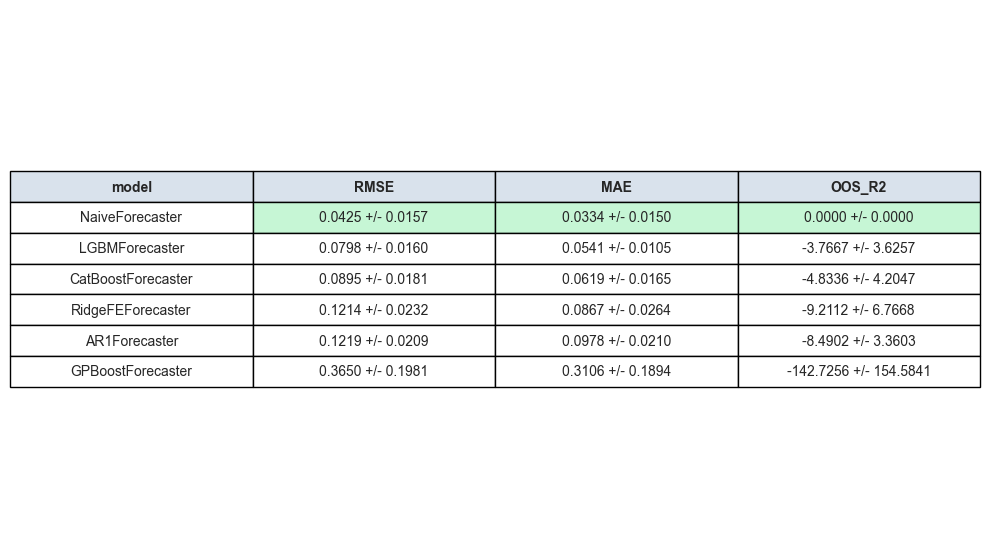

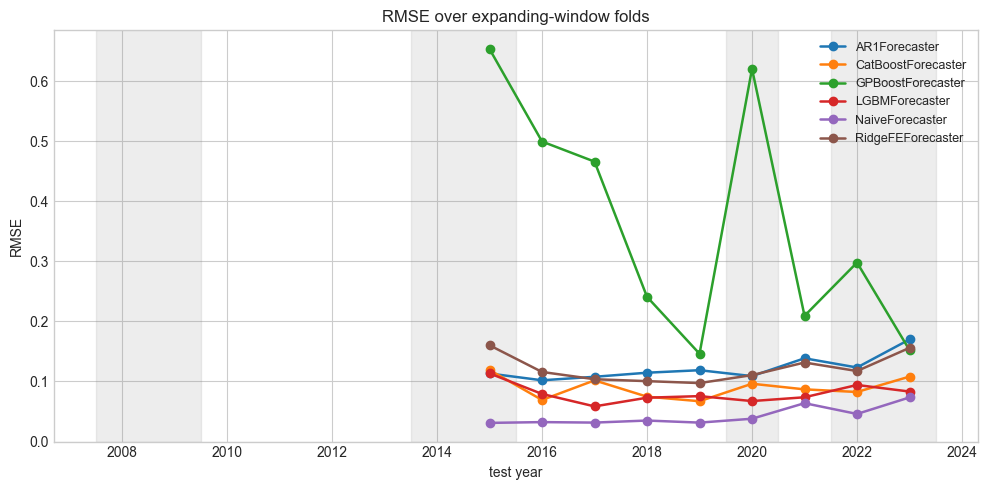

OOS R2 > 0: False


In [ ]:
fig = plot_metrics_table(agg)
fig.savefig("figures/metrics_table.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_metrics_over_time(cv_results, metric="RMSE")
fig.savefig("figures/rmse_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

test_oos_r2_naive_is_zero(folds)
oos_r2_check = agg[agg["model_name"] != "NaiveForecaster"]["OOS_R2_mean"]
print("OOS R2 > 0:", (oos_r2_check > 0).all())

## 4. Ablation study

Последовательное добавление групп признаков к лучшей ансамблевой модели:

| Сценарий | Признаки |
|----------|----------|
| A0 | LAG_BLOCK only (lag1, lag2, MA3, trend) |
| A1 | + PRODUCTION + INVESTMENT |
| A2 | + LABOUR + BUDGET |
| A3 | Все блоки (полная модель) |

Позволяет оценить предельный вклад каждой группы признаков в точность прогноза.

Лучший ансамбль: LGBMForecaster


,RMSE,MAE,OOS_R2
scenario,,,
A0,0.0545,0.0383,-0.8930
A1,0.0644,0.0452,-1.9227
A2,0.0539,0.0401,-0.8669
A3,0.0772,0.0539,-3.1552


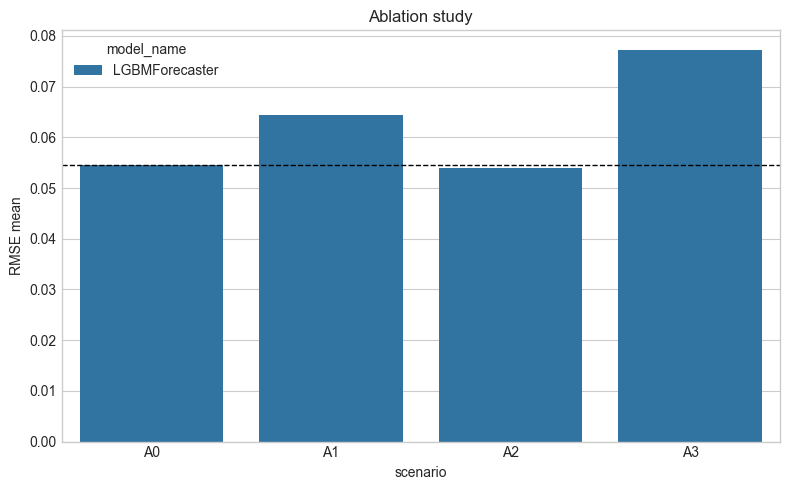

In [ ]:
ensemble_names = ["LGBMForecaster", "CatBoostForecaster", "GPBoostForecaster"]
best_name = agg[agg["model_name"].isin(ensemble_names)].iloc[0]["model_name"]
best_cls = {m.name: type(m) for m in models}[best_name]
print(f"Лучший ансамбль: {best_name}")

feature_groups = {}
for fold in folds:
    for group, columns in fold.get("feature_groups", {}).items():
        feature_groups.setdefault(group, [])
        feature_groups[group].extend(columns)
feature_groups = {
    group: list(dict.fromkeys(columns))
    for group, columns in feature_groups.items()
}

ablation_res = run_ablation_study(best_cls, folds, feature_groups)
ablation_agg = ablation_res.groupby("scenario")[["RMSE", "MAE", "OOS_R2"]].mean().round(4)
display(ablation_agg)

fig = plot_ablation(ablation_res)
fig.savefig("figures/ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Robustness checks

**RC1 — исключение регионов-выбросов**: удаляются Москва, ХМАО, ЯНАО, Сахалинская обл.  
Проверяет, не обусловлены ли результаты несколькими крупными ресурсными регионами.

**RC2 — кризисные vs. нормальные годы**: тест-фолды разделяются на кризисные  
(2008–09, 2014–15, 2020, 2022–23) и остальные. Оценивается устойчивость качества прогноза  
в условиях экономических потрясений.

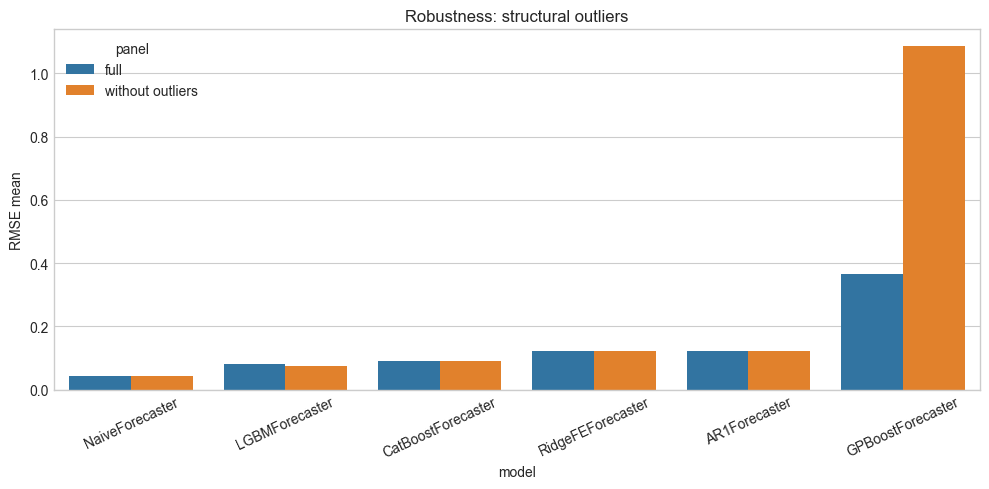

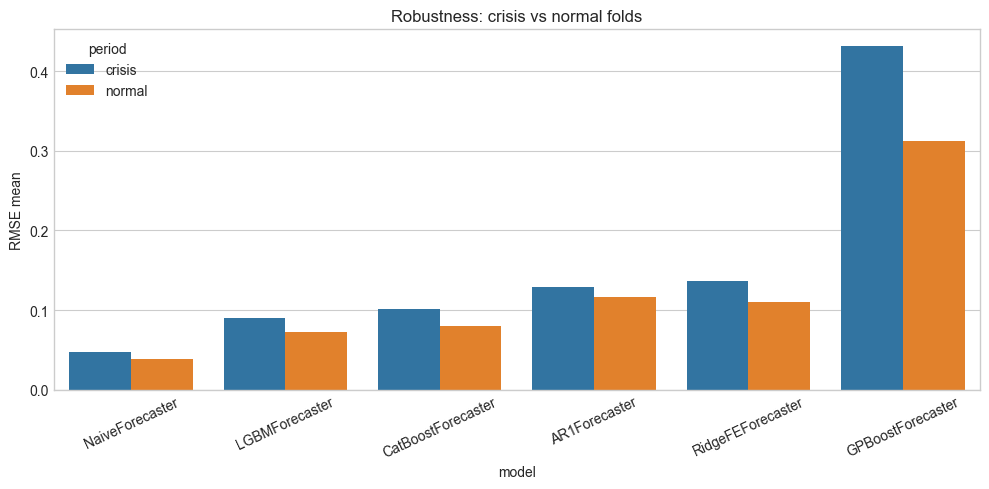

RC1 top-1: NaiveForecaster
RC2 crisis top-1: NaiveForecaster
RC2 normal top-1: NaiveForecaster


In [ ]:
rc1_results = robustness_check_outliers(
    models,
    folds,
    outlier_region_ids=CONFIG["robustness"]["outlier_region_ids"],
)
rc1_agg = aggregate_results(rc1_results)
fig = plot_robustness_outliers(agg, rc1_agg)
fig.savefig("figures/rc1_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

rc2_results = robustness_check_crisis(
    models,
    folds,
    crisis_years=CONFIG["robustness"]["crisis_years"],
)
fig = plot_robustness_crisis(rc2_results)
fig.savefig("figures/rc2_crisis.png", dpi=150, bbox_inches="tight")
plt.show()

print("RC1 top-1:", rc1_agg.iloc[0]["model_name"])
print("RC2 crisis top-1:", rc2_results["crisis"].iloc[0]["model_name"] if not rc2_results["crisis"].empty else "нет данных")
print("RC2 normal top-1:", rc2_results["normal"].iloc[0]["model_name"] if not rc2_results["normal"].empty else "нет данных")

## 6. SHAP-интерпретация

Применяется `shap.TreeExplainer` к лучшей **древесной** модели (LGBM / CatBoost / GPBoost).  
Если лучшая модель — `EmbMLPForecaster`, для интерпретации выбирается лучший среди деревьев.

Выходы:
- **Глобальная важность**: средний |SHAP| по всем наблюдениям
- **Beeswarm-plot**: распределение SHAP-значений для топ-N признаков
- **Group heatmap**: вклад блоков признаков по типу региона
- **Локальные примеры**: waterfall-объяснение для по одному региону каждого типа

In [ ]:
X_test_all = pd.concat([fold["X_test"] for fold in folds], axis=0)
y_test_all = pd.concat([fold["y_test"] for fold in folds], axis=0)

predict_growth = CONFIG["validation"].get("predict_growth", False)
TREE_MODELS = {"LGBMForecaster", "CatBoostForecaster", "GPBoostForecaster"}
shap_model_name = best_name if best_name in TREE_MODELS else (
    agg[agg["model_name"].isin(TREE_MODELS)].iloc[0]["model_name"]
    if not agg[agg["model_name"].isin(TREE_MODELS)].empty else best_name
)
best_model_inst = [m for m in get_all_models(CONFIG["models"], predict_growth=predict_growth) if m.name == shap_model_name][0]
X_train_full = folds[-1]["X_train"]
y_train_full = folds[-1]["y_train"]
best_model_inst.fit(X_train_full, y_train_full)

region_meta_cols = [col for col in ["region_id", "region_type", "region_name"] if col in df.columns]
region_meta = df[region_meta_cols].drop_duplicates("region_id").copy()
if "region_type" not in region_meta.columns:
    region_meta["region_type"] = "unknown"
if "region_name" not in region_meta.columns:
    region_meta["region_name"] = region_meta["region_id"]

shap_dict = run_shap_analysis(best_model_inst, X_test_all, feature_groups, region_meta)


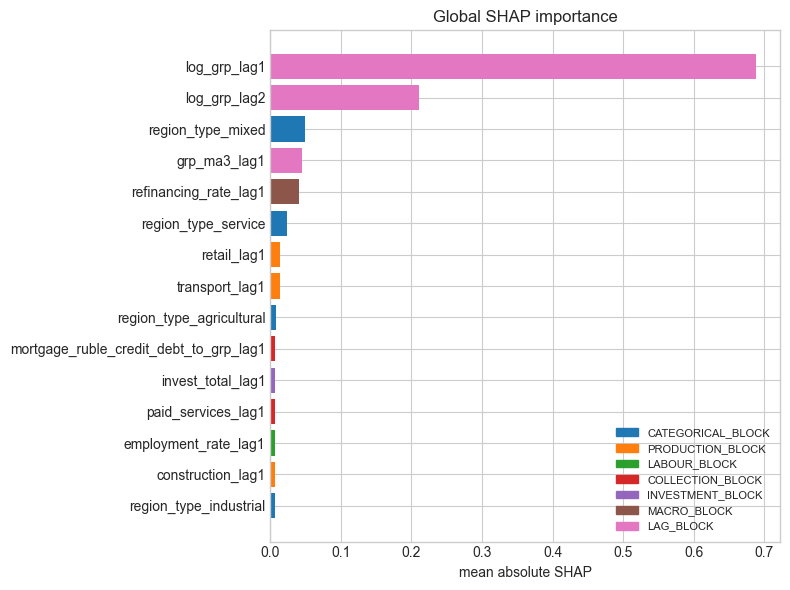

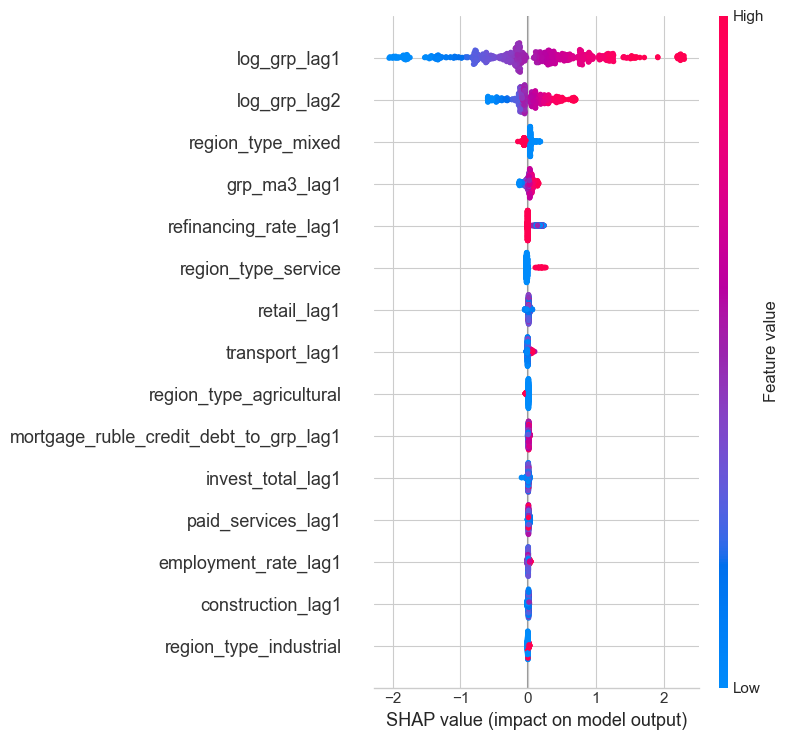

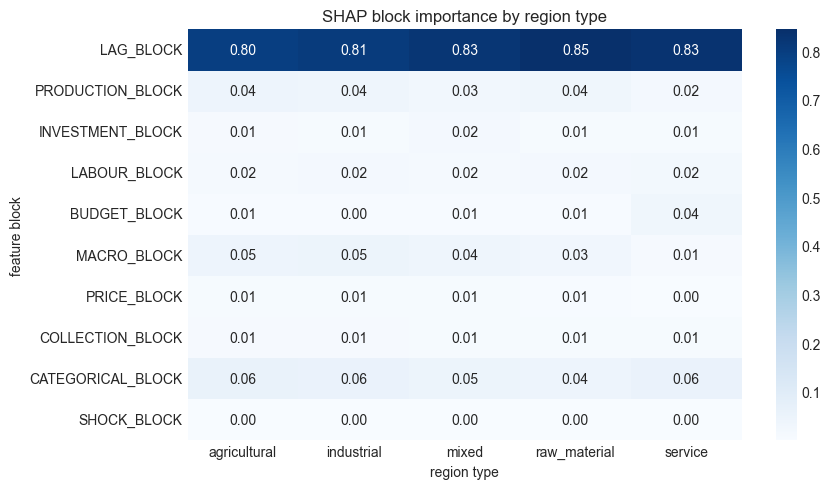

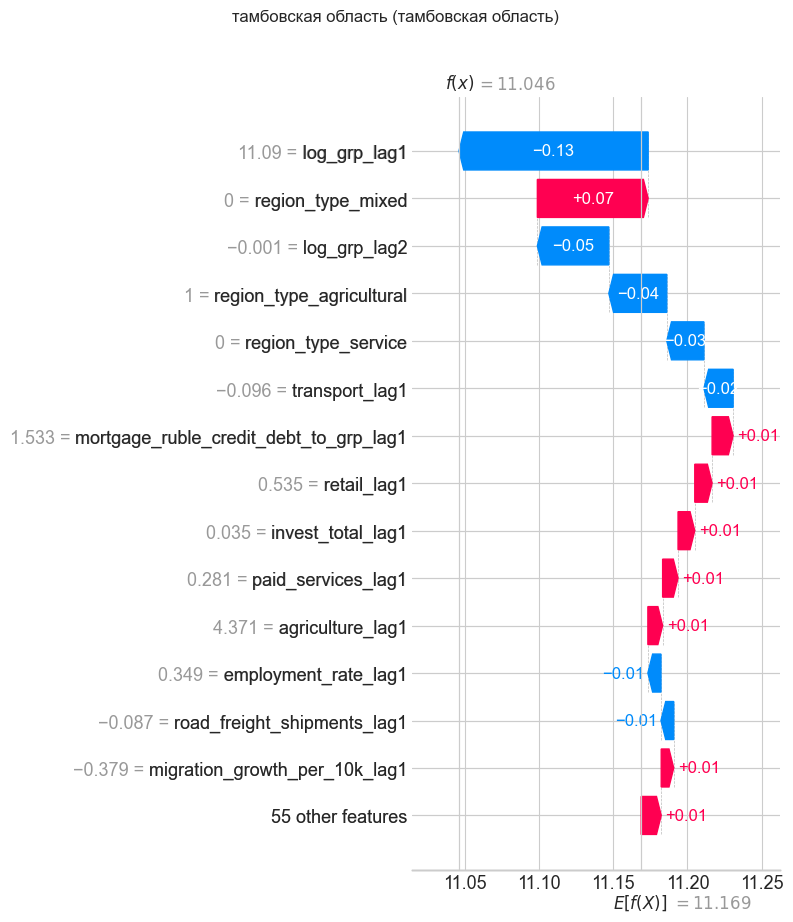

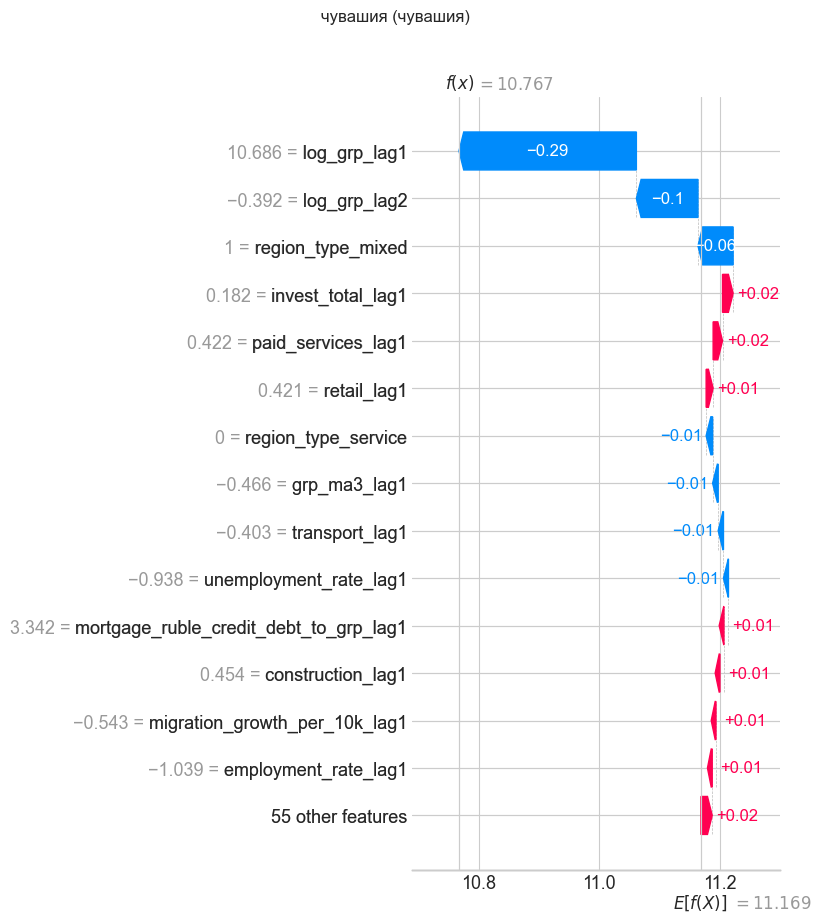

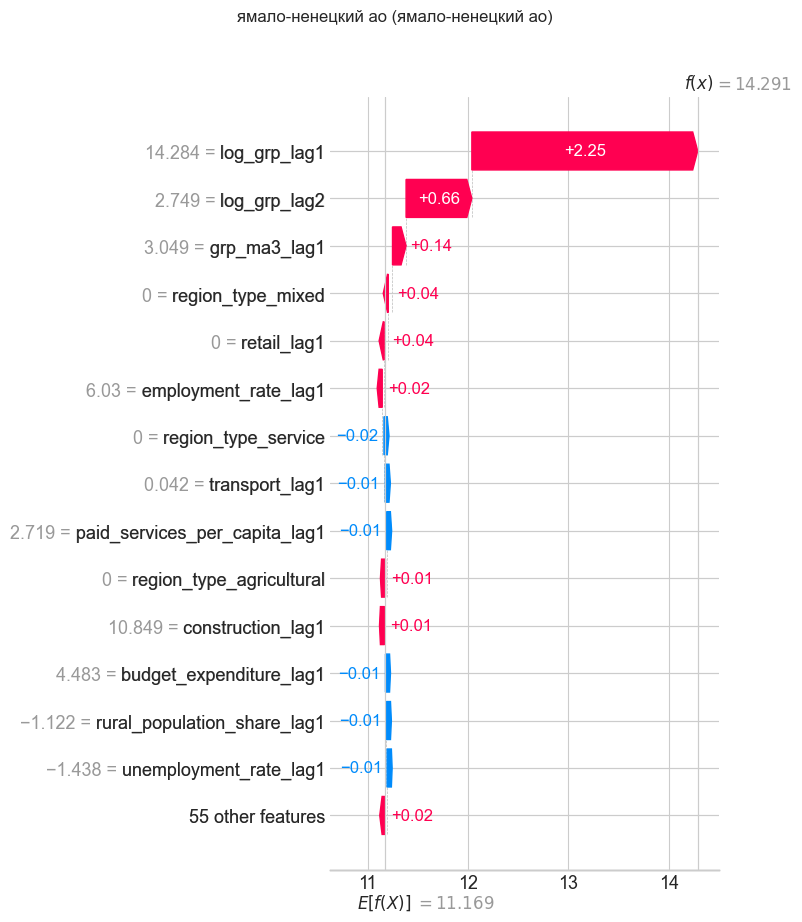

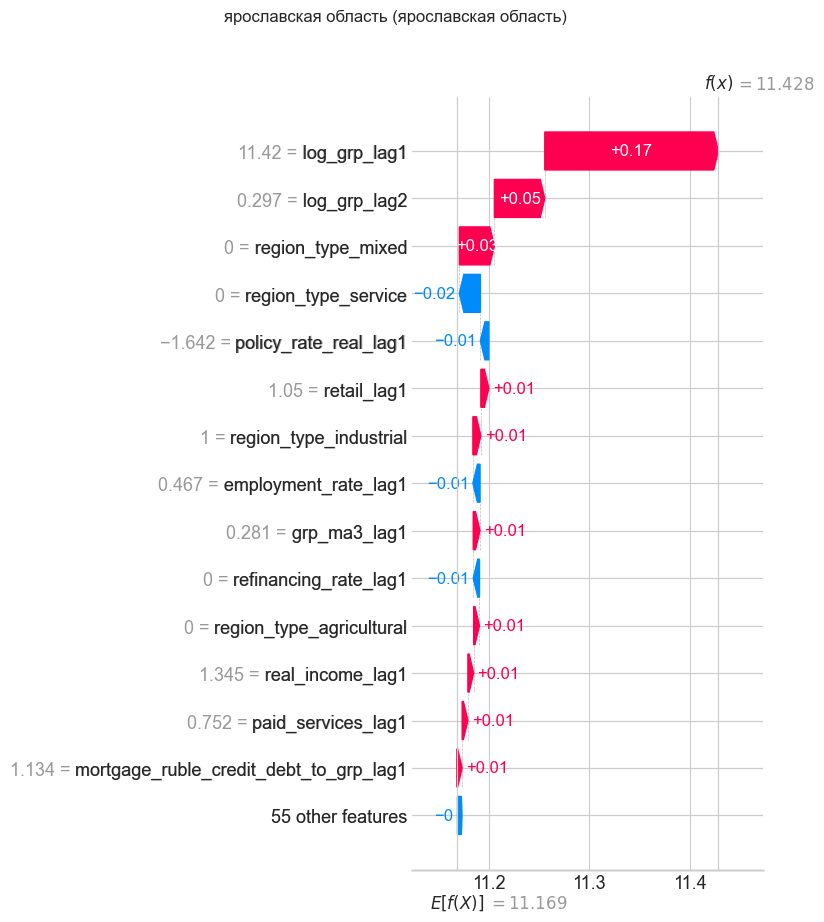

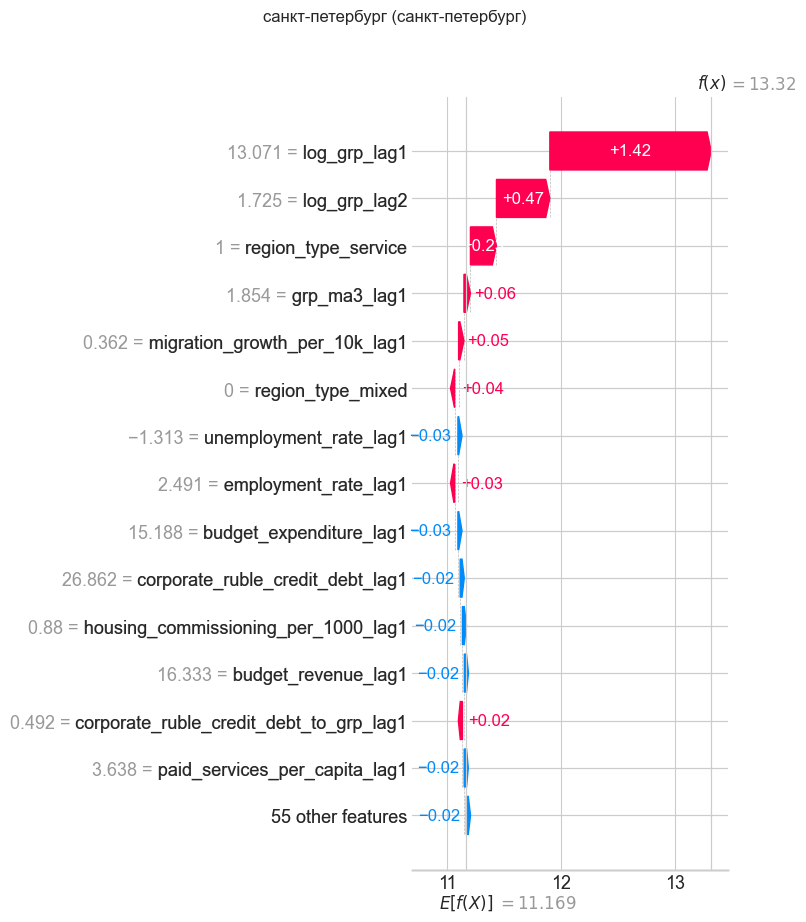

In [ ]:
fig = plot_shap_global(shap_dict, top_n=CONFIG["shap"]["top_n_features"])
fig.savefig("figures/shap_global.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_shap_beeswarm(shap_dict, top_n=CONFIG["shap"]["top_n_features"])
fig.savefig("figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_shap_group_heatmap(shap_dict)
fig.savefig("figures/shap_group_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

for ex_id, ex_name in shap_dict["local_examples"].items():
    fig = plot_shap_local(shap_dict, ex_id, ex_name)
    fig.savefig(f"figures/shap_local_{ex_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Анализ ошибок

Детальный разбор остатков лучшей модели по трём измерениям:

- **По регионам**: топ-20 регионов с наибольшим MAE — позволяет выявить систематически трудные субъекты
- **По годам**: динамика MAE всех моделей — видны кризисные всплески ошибок
- **Тепловая карта**: матрица ошибок регион × год для топ-30 регионов

In [ ]:
cv_results

,model_name,fold,test_year,n_obs,RMSE,MAE,OOS_R2
0,NaiveForecaster,1,2015,85,0.031035,0.023326,0.000000
1,AR1Forecaster,1,2015,85,0.113262,0.085852,-12.319055
2,RidgeFEForecaster,1,2015,85,0.160213,0.136123,-25.650455
3,LGBMForecaster,1,2015,85,0.113444,0.073804,-12.361902
4,CatBoostForecaster,1,2015,85,0.119078,0.086256,-13.722034
5,GPBoostForecaster,1,2015,85,0.653370,0.568526,-442.226352
6,NaiveForecaster,2,2016,85,0.032334,0.022286,0.000000
7,AR1Forecaster,2,2016,85,0.101949,0.079744,-8.941072
8,RidgeFEForecaster,2,2016,85,0.115816,0.085083,-11.829423
9,LGBMForecaster,2,2016,85,0.079211,0.054148,-5.001307


In [ ]:
CONFIG["data"]["processed_dir"]

'data/processed/'

In [ ]:
err = error_analysis(cv_results, predictions_dir=CONFIG["data"]["processed_dir"])

fig = plot_error_by_region(err, top_n=20)
fig.savefig("figures/error_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_error_heatmap(err)
fig.savefig("figures/error_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

ValueError: 'region_id' is both an index level and a column label, which is ambiguous.

## 8. Итоговые выводы

Сводка результатов: лучшая модель, улучшение над наивным бенчмарком (OOS R² и RMSE),  
топ-5 наиболее значимых признаков по SHAP.  

**Критерий победы над бенчмарком**: OOS R² > 0 (хотя бы на части фолдов) и RMSE ниже наивного прогноза.

In [ ]:
best_rmse = agg.iloc[0]
naive_rmse = agg[agg["model_name"] == "NaiveForecaster"]["RMSE_mean"].values[0]
improvement_pct = (naive_rmse - best_rmse["RMSE_mean"]) / naive_rmse * 100

top_features = "\n".join(
    f"  {idx + 1}. {feature}"
    for idx, feature in enumerate(shap_dict["global_importance"].head(5).index)
)

print(f"""
=== ИТОГОВЫЙ ВЫВОД ===
Лучшая модель: {best_rmse['model_name']}
RMSE (mean over folds): {best_rmse['RMSE_mean']:.4f}
MAE  (mean over folds): {best_rmse['MAE_mean']:.4f}
OOS R2 (mean):          {best_rmse['OOS_R2_mean']:.4f}

Улучшение RMSE vs. наивного прогноза: {improvement_pct:.1f}%

Наиболее важные признаки (топ-5 по SHAP):
{top_features}
""")


=== ИТОГОВЫЙ ВЫВОД ===
Лучшая модель: NaiveForecaster
RMSE (mean over folds): 0.0425
MAE  (mean over folds): 0.0334
OOS R2 (mean):          0.0000

Улучшение RMSE vs. наивного прогноза: 0.0%

Наиболее важные признаки (топ-5 по SHAP):
  1. log_grp_lag1
  2. log_grp_lag2
  3. region_type_mixed
  4. grp_ma3_lag1
  5. refinancing_rate_lag1

